In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import boto3

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Feb 18 09:13:15 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Feb 18 09:13:15 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def target_by_data_set(df, str_target, str_dirname_output='./output'):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    
    # save
    str_filename = 'plt_target.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')
    
    # show
    plt.show()

In [3]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [5]:
class OverSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # oversample zeros
    def oversample_zeros(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for the new n total to reach target
        int_n_total_new = math.ceil(int_n_ones_original / flt_target_value)
        # get n additional 0s
        int_n_additional_zeros = int_n_total_new - int_n_ones_original - int_n_zeros_original
        # get sample
        df_zeros_additional = df_zeros.sample(n=int_n_additional_zeros, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_zeros_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample ones
    def oversample_ones(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for number of 1s
        int_n_additional_ones = math.ceil((int_n_ones_original - (flt_target_value * int_n_total_original)) / (flt_target_value - 1))
        # get sample
        df_ones_additional = df_ones.sample(n=int_n_additional_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_ones_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.oversample_zeros()
        else:
            df = self.oversample_ones()
        # return
        return df

In [6]:
def get_logistic_regression_feat_importance(df, cls_model_inference, list_cols_model=None):
    try:
        list_cols_model = list(cls_model_inference.feature_names_in_)
    except:
        pass
    df_tmp = pd.DataFrame({
        'feature': list_cols_model,
        'importance': list(cls_model_inference.coef_[0]),
    })
    # make into dictionary
    dict_coef = dict(zip(df_tmp['feature'], df_tmp['importance']))
    # subset df
    df_tmp = df[list_cols_model].copy()
    # iterate
    for key, val in dict_coef.items():
        # multiply the feature by the coefficient
        df_tmp[key] = df_tmp[key] * val
    # get the mean for each
    list_dict_row = []
    for col in list_cols_model:
        flt_mean = df_tmp[col].mean()
        dict_row = {
            'feature': col,
            'importance': flt_mean,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make abs value
    df_tmp['importance_abs'] = df_tmp['importance'].apply(abs)
    # sort    
    df_tmp.sort_values(by='importance_abs', ascending=False, inplace=True)
    # return
    return df_tmp

In [7]:
# ks
def get_ks_score(y_true, y_pred):
    fpr, tpr, _ = skm.roc_curve(
        y_true=y_true,
        y_score=y_pred,
    )
    ks_stat = max(tpr - fpr)
    return ks_stat

In [8]:
def evaluate(y_train, list_predictions_train, y_test, list_predictions_test, y_holdout, list_predictions_holdout):
    # get auc
    flt_auc_train = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_train,
    )
    print(f'AUC Train: {flt_auc_train:0.4f}')
    flt_auc_test = skm.roc_auc_score(
        y_true=y_test,
        y_score=list_predictions_test,
    )
    print(f'AUC Test: {flt_auc_test:0.4f}')
    flt_auc_holdout = skm.roc_auc_score(
        y_true=y_holdout,
        y_score=list_predictions_holdout,
    )
    print(f'AUC Holdout: {flt_auc_holdout:0.4f}')
    print()
    # logloss
    flt_logloss_train = skm.log_loss(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'Logloss Train: {flt_logloss_train:0.4f}')
    flt_logloss_test = skm.log_loss(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'Logloss Test: {flt_logloss_test:0.4f}')
    flt_logloss_holdout = skm.log_loss(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'Logloss Holdout: {flt_logloss_holdout:0.4f}')
    print()
    # ks
    flt_ks_train = get_ks_score(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'KS Train: {flt_ks_train:0.4f}')
    flt_ks_test = get_ks_score(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'KS Test: {flt_ks_test:0.4f}')
    flt_ks_holdout = get_ks_score(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'KS Holdout: {flt_ks_holdout:0.4f}')
    return flt_auc_train, flt_auc_test

In [9]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    
    # save
    str_filename = 'performance.png'
    str_local_path = f'./output/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')
    
    # show
    plt.show()

In [10]:
def get_directions_of_predictions_for_scorecard(X, list_predictions, str_target, list_actual, list_cols, df_bins):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # map bin label
        df_bins_tmp = df_bins[df_bins['feature'] == col].copy()
        # create dict
        dict_map_bin = dict(zip(df_bins_tmp['bin'], df_bins_tmp['bin_label']))
        # map
        X['bin_label'] = X[col].map(dict_map_bin)
        # group
        df_tmp = X.groupby(by='bin_label', as_index=False).agg({
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='bin_label', ascending=True, inplace=True)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Bin (Ascending)')
        ax.set_xlabel(f'{col} Bin')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [11]:
def weight_the_coefficients(cls_model_inference, dict_weights):
    # features and coefficients
    list_feature_names_in = list(cls_model_inference.feature_names_in_)
    arr_coef = cls_model_inference.coef_[0]
    # multiply by weights and reassign
    for key, val in dict_weights.items():
        try:
            # get idx of feature
            int_idx = list_feature_names_in.index(key)
            # get the coef
            flt_coef = arr_coef[int_idx]
            # multiply by weight
            flt_coef = flt_coef * val
            # reassign
            arr_coef[int_idx] = flt_coef
        except ValueError:
            pass
    # reassign into model
    cls_model_inference.coef_[0] = arr_coef
    # return
    return cls_model_inference

In [12]:
def prep_for_partial_score(list_predictions, y_actual, flt_prop_pred=0.6):
    df_pred = pd.DataFrame({
        'pred': list_predictions,
        'actual': y_actual,
    })
    df_pred.sort_values(by='pred', ascending=True, inplace=True)
    # get rows
    int_nrows_subset = int(flt_prop_pred * len(df_pred))
    df_pred = df_pred.iloc[:int_nrows_subset].copy()
    # return
    return df_pred

In [13]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # upload
    cls_client.upload_file(
        str_local_path, 
        str_bucket_name, 
        str_bucket_key,
    )

#### Constants

In [14]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target_tmp = str_task[3:].replace('_in_','_').replace('_dl','')
str_target = f'Early_Pay_Delinquency_{str_target_tmp}_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

# number of columns in scorecard plot
int_ncols = 5

# weights
dict_weights = {
    'ENG-loan_to_value_binned': 1.0,
    'g106s__tu_binned': 1.0,
}

flt_prop_pred = 1.0

Project: 20241112-simple-model-test
Task: 13_60_in_720_dl
Subtask: 02_model
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [15]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [16]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Hard code some bad features

In [17]:
list_cols_bad = [
    'agg904__tu',
    'cv17__tu',
    'fi21s__tu',
    'g219a__tu',
    'g244f__tu',
    'g306s__tu',
    'in36s__tu',
    'int_30dpd_open__tu_pmthx',
    'linka027__tu',
    'of02s__tu',
    're06s__tu',
    'trv03__tu',
    'cv13__tu',
    # hurts train auc
    'trv09__tu',
    # doesnt make sense
    'linkt002__tu',
    'g102s__tu',
    'g310s__tu',
    'rvlr64__tu',
    # compliance
    'us101s__tu',
]

#### Hard code features we want

In [18]:
list_cols_force = [
]

#### Get the features

In [19]:
str_filename = 'df_feat_imp.csv'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
df_feat_imp = pd.read_csv(str_local_path)
df_feat_imp['feature'] = df_feat_imp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
# rm bad
df_feat_imp = df_feat_imp[~df_feat_imp['feature'].isin(list_cols_bad)].copy()
# get list of columns in the model
list_cols_model = list(df_feat_imp['feature'])
# add forced
list_cols_model = list_cols_model + list_cols_force
# rm dups
list_cols_model = list(dict.fromkeys(list_cols_model))
# get number of features
int_n_feats_final_scorecard = len(list_cols_model)
print(f'There are {int_n_feats_final_scorecard} features from which to select')
# rows for scorecard graph
int_nrows = math.ceil(int_n_feats_final_scorecard / int_ncols)
# show
df_feat_imp

There are 33 features from which to select


,feature,importance,importance_abs,description
0,rev326__tu,-0.015389,0.015389,Average Total Open-to-Buy for Revolving accoun...
1,au20s__tu,-0.013869,0.013869,Months since oldest auto trade opened
2,linkt001__tu,-0.012772,0.012772,Number of non-military addresses in last 7 years
4,miles_odometer__app,0.011318,0.011318,NaN
5,balmag01__tu,-0.011225,0.011225,Non-mortgage balance magnitude algorithm over ...
6,fltgrossmonthly__income_sum,-0.010642,0.010642,NaN
7,br109s__tu,-0.010270,0.010270,Number of bank revolving trades with past due ...
8,int_n_months_open__tu_pmthx,-0.008547,0.008547,NaN
9,rtl_trd__tu,-0.008445,0.008445,Number of retail trades
11,ENG-loan_to_value,0.007516,0.007516,NaN


#### Import data

In [20]:
list_cols_import = [
    'data_set',
    'request_datetime',
    'days_on_books',
    'applicationdate__app',
    'accountid',
    'bitdebtor__app',
    str_target,
    'ENG-loan_to_value',
    'ENG-bk',
    'ENG-franchise',
    'ENG-has_codebtor',
    'fltgrossmonthly__income_sum', # income
    'ENG-payment_to_income', # payment to income
    'ENG-dti',
    'ENG-wtd_avg',
]

# add features
list_cols_import = list_cols_import + list_cols_model
# rm dups
list_cols_import = list(dict.fromkeys(list_cols_import))
# import
list_str_filename = [
    'train',
    'test',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
        columns=list_cols_import,
    )
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# make dt
df['request_date'] = df['request_datetime'].apply(
    lambda x: str(x)[:10],
)
df['request_date'] = pd.to_datetime(df['request_date']).dt.date
# save memory
del list_df
# show
df

100%|██████████| 3/3 [00:05<00:00,  1.88s/it]


,data_set,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,...,per235__tu,co01s__tu,st20s__tu,fi36s__tu,fi25s__tu,in21s__tu,aut252__tu,flt_wtd_avg_open__tu_pmthx,s068b__tu,request_date
0,train,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,...,752.0,3.0,174.0,1.0,NaN,8.0,NaN,NaN,NaN,2021-07-26
1,train,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,...,174.0,0.0,NaN,999.0,NaN,2.0,NaN,NaN,2.0,2021-07-26
2,train,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,...,NaN,0.0,172.0,NaN,NaN,172.0,NaN,NaN,NaN,2021-07-26
3,train,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,0,1.081881,0,0,...,NaN,1.0,237.0,5.0,NaN,12.0,NaN,NaN,0.0,2021-07-27
4,train,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,...,NaN,0.0,NaN,NaN,NaN,68.0,NaN,NaN,NaN,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,holdout,2022-11-30 23:45:32+00:00,793,2022-11-21 11:18:11.910,6453589,1,0,1.478650,0,1,...,0.0,2.0,138.0,0.0,0.0,4.0,0.0,0.133005,NaN,2022-11-30
41694,holdout,2022-11-30 23:48:36+00:00,793,2022-11-02 09:31:34.827,6418453,1,0,1.090807,0,0,...,NaN,0.0,NaN,1.0,NaN,18.0,NaN,0.384615,NaN,2022-11-30
41695,holdout,2022-11-30 23:53:12+00:00,793,2022-10-28 18:33:19.217,6411914,1,1,1.352150,0,0,...,NaN,0.0,NaN,999.0,NaN,73.0,NaN,NaN,NaN,2022-11-30
41696,holdout,2022-11-30 23:57:04+00:00,793,2022-11-10 15:20:54.540,6434554,1,0,1.024680,1,1,...,NaN,0.0,NaN,1.0,NaN,45.0,NaN,0.137374,1.0,2022-11-30


#### Bad rate by BK by data set

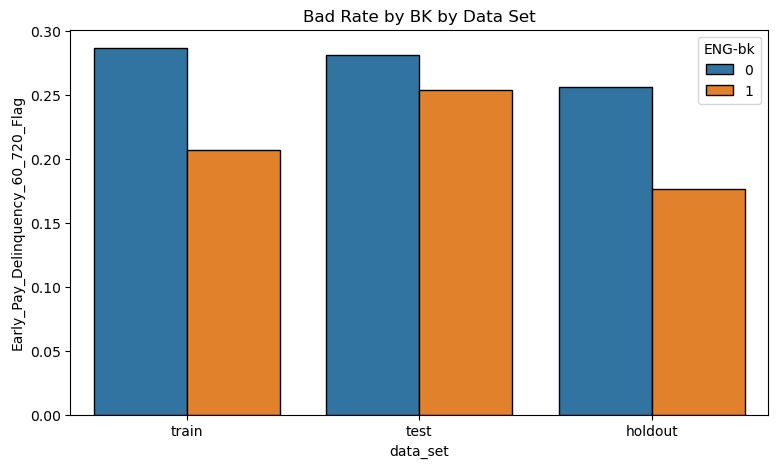

In [21]:
df_tmp = df.groupby(by=['data_set','ENG-bk'], as_index=False).agg({
    str_target: 'mean',
})
# sort
df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by=['sort','ENG-bk'], ascending=[True, True], inplace=True)
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by BK by Data Set')
sns.barplot(data=df_tmp, x='data_set', y=str_target, hue='ENG-bk', ax=ax, dodge=True, edgecolor='black')

# save
str_filename = 'plt_bad_bk_dataset.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Bad rate by franchise by data set

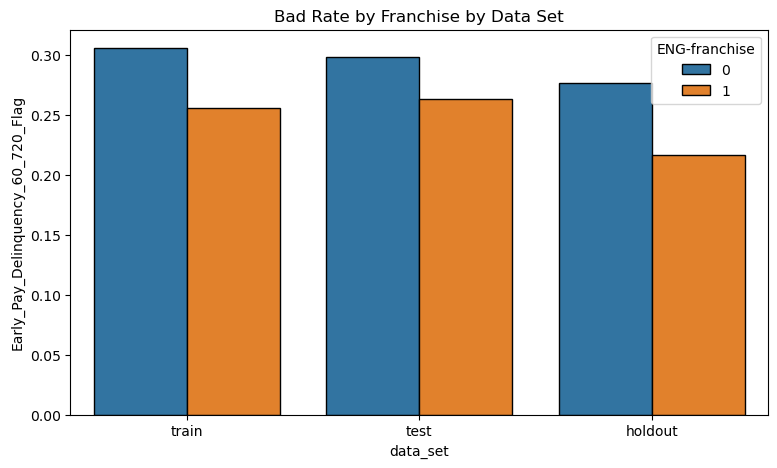

In [22]:
df_tmp = df.groupby(by=['data_set','ENG-franchise'], as_index=False).agg({
    str_target: 'mean',
})
# sort
df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by=['sort','ENG-franchise'], ascending=[True, True], inplace=True)
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by Franchise by Data Set')
sns.barplot(data=df_tmp, x='data_set', y=str_target, hue='ENG-franchise', ax=ax, dodge=True, edgecolor='black')

# save
str_filename = 'plt_bad_franchise_dataset.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Make table into a png image

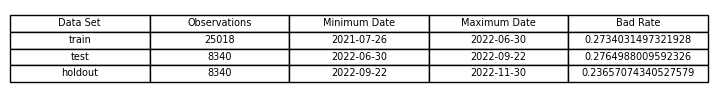

In [23]:
df['rows'] = 1
df['min_date'] = df['request_date']
df['max_date'] = df['request_date']
df_grouped = df.groupby(by='data_set', as_index=False).agg({
    'rows': 'count',
    'min_date': 'min',
    'max_date': 'max',
    str_target: 'mean',
})
# sort
df_grouped['sort'] = df_grouped['data_set'].map(dict_sort)
df_grouped.sort_values(by='sort', ascending=True, inplace=True)
df_grouped.drop('sort', axis=1, inplace=True)
# rename
dict_rename = {
    'data_set': 'Data Set',
    'rows': 'Observations',
    'min_date': 'Minimum Date',
    'max_date': 'Maximum Date',
    str_target: 'Bad Rate',
}
df_grouped.rename(columns=dict_rename, inplace=True)

# save
str_filename = 'df_info.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_grouped.to_csv(str_local_path, index=False)

# make into png
fig, ax = plt.subplots(figsize=(9,1))
ax.axis('tight')
ax.axis('off')
ax.table(cellText=df_grouped.values, colLabels=df_grouped.columns, cellLoc='center', loc='center')

# save
str_filename = 'plt_info.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

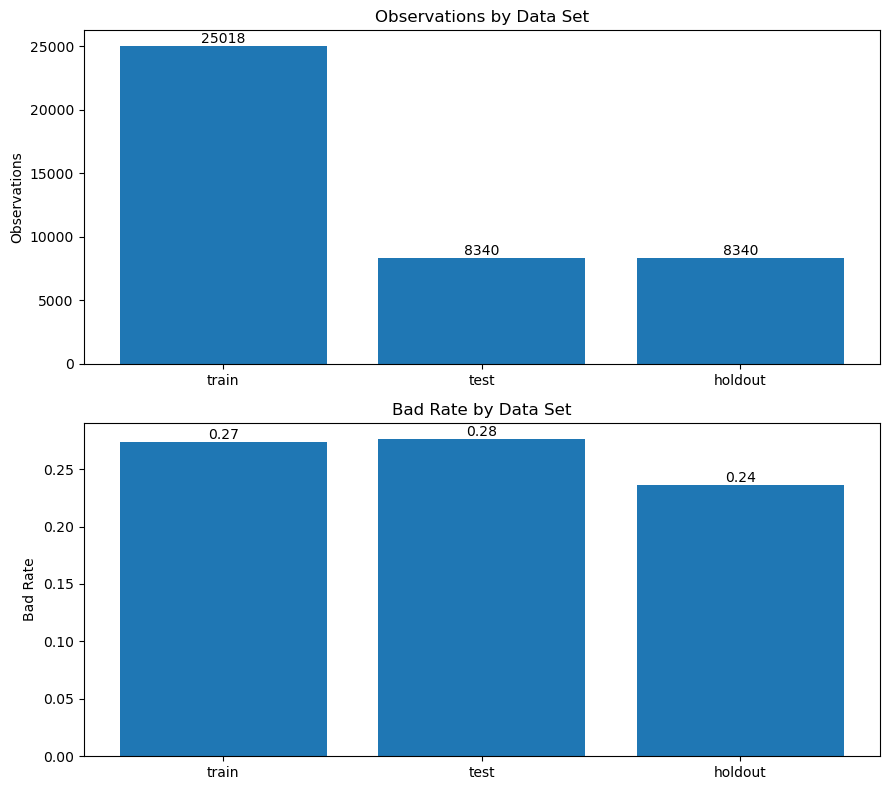

In [24]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(9,8))
# top plot
ax[0].set_title('Observations by Data Set')
ax[0].set_ylabel('Observations')
bars = ax[0].bar(df_grouped['Data Set'], df_grouped['Observations'])
ax[0].bar_label(bars)
# bottom plot
ax[1].set_title('Bad Rate by Data Set')
ax[1].set_ylabel('Bad Rate')
bars = ax[1].bar(df_grouped['Data Set'], df_grouped['Bad Rate'])
ax[1].bar_label(bars, fmt='%.2f')
# fix overlap
plt.tight_layout()

# save
str_filename = 'plt_info_img.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Target mean by data set

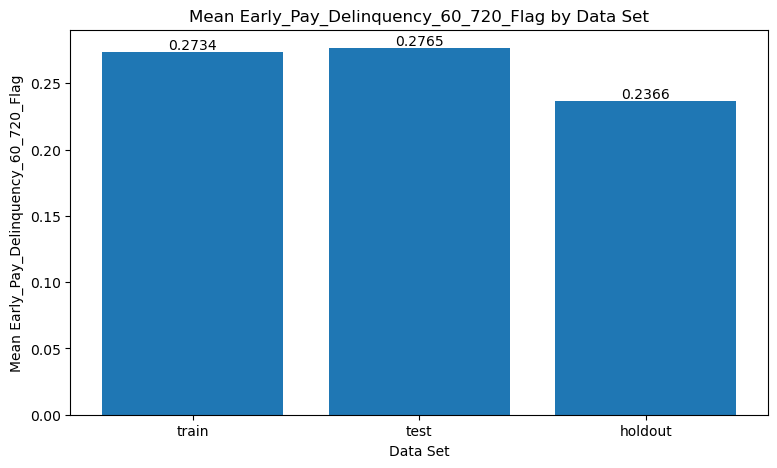

In [25]:
target_by_data_set(
    df=df,
    str_target=str_target,
)

#### Get relationship with target in training data

In [26]:
# import
str_filename = 'dict_monotone_constraints.pkl'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
dict_monotone_constraints = pickle.load(open(str_local_path, 'rb'))

#### Create dictionary for imputation

In [27]:
# import
str_filename = 'dict_impute.pkl'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        # replace any infs with nan
        df[key] = df[key].replace(np.inf, np.nan)
        # fillna
        df[key] = df[key].fillna(val)
    except KeyError:
        pass
# show
df

100%|██████████| 988/988 [00:00<00:00, 10695.28it/s]


,data_set,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_60_720_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,...,fi36s__tu,fi25s__tu,in21s__tu,aut252__tu,flt_wtd_avg_open__tu_pmthx,s068b__tu,request_date,rows,min_date,max_date
0,train,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,...,1.0,0.0,8.0,0.0,0.000000,18.0,2021-07-26,1,2021-07-26,2021-07-26
1,train,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,...,999.0,0.0,2.0,0.0,0.000000,2.0,2021-07-26,1,2021-07-26,2021-07-26
2,train,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,...,0.0,0.0,172.0,0.0,0.000000,18.0,2021-07-26,1,2021-07-26,2021-07-26
3,train,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,0,1.081881,0,0,...,5.0,0.0,12.0,0.0,0.000000,0.0,2021-07-27,1,2021-07-27,2021-07-27
4,train,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,...,0.0,0.0,68.0,0.0,0.000000,18.0,2021-07-27,1,2021-07-27,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,holdout,2022-11-30 23:45:32+00:00,793,2022-11-21 11:18:11.910,6453589,1,0,1.478650,0,1,...,0.0,0.0,4.0,0.0,0.133005,18.0,2022-11-30,1,2022-11-30,2022-11-30
41694,holdout,2022-11-30 23:48:36+00:00,793,2022-11-02 09:31:34.827,6418453,1,0,1.090807,0,0,...,1.0,0.0,18.0,0.0,0.384615,18.0,2022-11-30,1,2022-11-30,2022-11-30
41695,holdout,2022-11-30 23:53:12+00:00,793,2022-10-28 18:33:19.217,6411914,1,1,1.352150,0,0,...,999.0,0.0,73.0,0.0,0.000000,18.0,2022-11-30,1,2022-11-30,2022-11-30
41696,holdout,2022-11-30 23:57:04+00:00,793,2022-11-10 15:20:54.540,6434554,1,0,1.024680,1,1,...,1.0,0.0,45.0,0.0,0.137374,1.0,2022-11-30,1,2022-11-30,2022-11-30


#### Get bins

In [28]:
# import
str_filename = 'dict_bins.pkl'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# transform
for key, val in tqdm(dict_bins.items()):
    try:
        df[f'{key}_binned'] = val.transform(df[key])
    except KeyError:
        pass

100%|██████████| 982/982 [00:00<00:00, 8192.02it/s]


In [29]:
# get scorecard names
list_cols_scorecard = [f'{col}_binned' for col in list_cols_model]

# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_scorecard):
    int_n_unique = df[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
for a, col in enumerate(list_col_no_var):
    print(f'{a+1} - {col}')
# rm
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_col_no_var]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

100%|██████████| 33/33 [00:00<00:00, 1304.24it/s]

There are 0 features with no variance after binning
There are 33 features available for scorecard inclusion


In [30]:
# show bins
str_filename = 'df_bins.csv'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
df_bins = pd.read_csv(str_local_path)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.112058,0.00,3245.72,8676,0.346790,0.296219,1
1,fltgrossmonthly__income_sum_binned,-0.088137,3245.83,3776.38,3660,0.146295,0.291257,2
2,fltgrossmonthly__income_sum_binned,0.034510,3776.64,4116.67,2048,0.081861,0.266602,3
3,fltgrossmonthly__income_sum_binned,0.042981,4116.89,4879.90,3880,0.155088,0.264948,4
4,fltgrossmonthly__income_sum_binned,0.053438,4880.18,5280.26,1529,0.061116,0.262917,5
...,...,...,...,...,...,...,...,...
2448,int_bad_6mo_closed__tu_pmthx_binned,-0.083606,1.00,1.00,14880,0.594772,0.290323,2
2449,int_bad_3mo_closed_end__tu_pmthx_binned,0.235304,0.00,0.00,5209,0.208210,0.229219,1
2450,int_bad_3mo_closed_end__tu_pmthx_binned,-0.057739,1.00,1.00,19809,0.791790,0.285022,2
2451,int_bad_6mo_closed_end__tu_pmthx_binned,0.191972,0.00,0.00,5178,0.206971,0.236964,1


#### Get info from inform set

In [31]:
# # get the inform data set
# df_inform = df[df['data_set'] == 'holdout'].copy()
# # get target value
# flt_target_value = df_inform[str_target].mean()
# print(f'Target Value: {flt_target_value:0.4f}')

#### Get train to match the inform set

In [32]:
# %%time

# get the training data
df_train = df[df['data_set'] == 'train'].copy()

# # get current target mean
# flt_current_value = df_train[str_target].mean()
# print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# # init
# cls_sample = OverSampling(
#     df=df_train,
#     str_target=str_target,
#     flt_target_value=flt_target_value,
#     flt_current_value=flt_current_value,
# )
# # sample
# df_train = cls_sample.sample()
# # get current target mean
# flt_current_value = df_train[str_target].mean()
# print(f'Target Value After Sampling: {flt_current_value:0.4f}')
# print()
# # show
# df_train

#### Get test to match the inform set

In [33]:
# %%time

# test
df_test = df[df['data_set'] == 'test'].copy()

# # get current target mean
# flt_current_value = df_test[str_target].mean()
# print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# # init
# cls_sample = OverSampling(
#     df=df_test,
#     str_target=str_target,
#     flt_target_value=flt_target_value,
#     flt_current_value=flt_current_value,
# )
# # sample
# df_test = cls_sample.sample()
# # get current target mean
# flt_current_value = df_test[str_target].mean()
# print(f'Target Value After Sampling: {flt_current_value:0.4f}')
# print()
# # show
# df_test

#### List of columns to start

In [34]:
print(f'Starting with {len(list_cols_scorecard)} features:')
for a, col in enumerate(list_cols_scorecard):
    print(f'{a+1}: {col}')

Starting with 33 features:
1: rev326__tu_binned
2: au20s__tu_binned
3: linkt001__tu_binned
4: miles_odometer__app_binned
5: balmag01__tu_binned
6: fltgrossmonthly__income_sum_binned
7: br109s__tu_binned
8: int_n_months_open__tu_pmthx_binned
9: rtl_trd__tu_binned
10: ENG-loan_to_value_binned
11: trv10__tu_binned
12: trv13__tu_binned
13: cv15__tu_binned
14: rp01s__tu_binned
15: jt20s__tu_binned
16: linkt003__tu_binned
17: g002s__tu_binned
18: g407s__tu_binned
19: g232s__tu_binned
20: flt_wtd_avg_closed__tu_pmthx_binned
21: linkf098__tu_binned
22: linka003__tu_binned
23: in30s__tu_binned
24: linka006__tu_binned
25: per235__tu_binned
26: co01s__tu_binned
27: st20s__tu_binned
28: fi36s__tu_binned
29: fi25s__tu_binned
30: in21s__tu_binned
31: aut252__tu_binned
32: flt_wtd_avg_open__tu_pmthx_binned
33: s068b__tu_binned


#### Split into X and y

In [35]:
# train
X_train = df_train[[col for col in list_cols_scorecard if col != str_target]].copy()
y_train = df_train[str_target]
# save memory
del df_train

In [36]:
# test
X_test = df_test[[col for col in list_cols_scorecard if col != str_target]].copy()
y_test = df_test[str_target]
# save memory
del df_test

In [37]:
# holdout
df_tmp = df[df['data_set'] == 'holdout'].copy()
X_holdout = df_tmp[[col for col in list_cols_scorecard if col != str_target]].copy()
y_holdout = df_tmp[str_target]
# assign
X_holdout['ENG-bk'] = df_tmp['ENG-bk']
X_holdout['ENG-franchise'] = df_tmp['ENG-franchise']
# save memory
del df, df_tmp

#### Scorecard

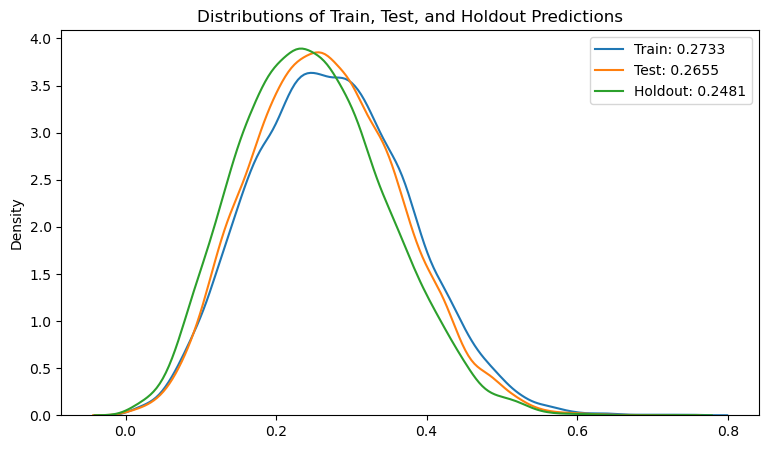

In [38]:
# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
#     penalty='l1',
#     solver='liblinear',
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [39]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6482
AUC Test: 0.6504
AUC Holdout: 0.6329

Logloss Train: 0.5587
Logloss Test: 0.5613
Logloss Holdout: 0.5269

KS Train: 0.2164
KS Test: 0.2219
KS Holdout: 0.2002


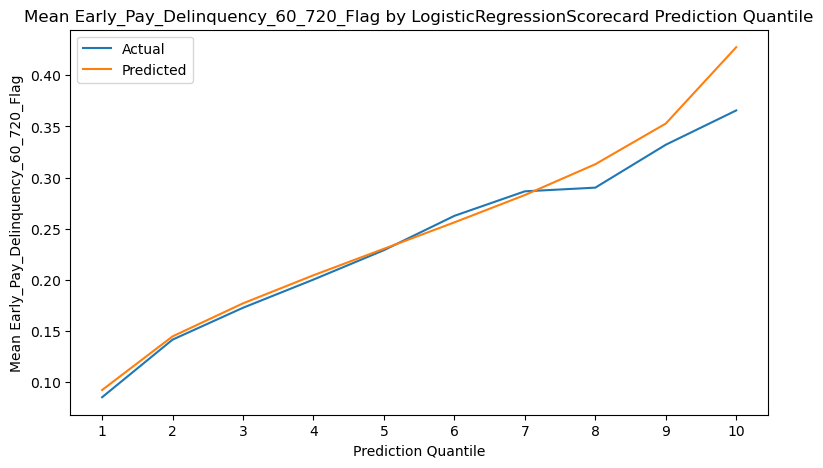

In [40]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

#### Sensitivity tuning/analysis

In [41]:
flt_auc_train_start = flt_auc_train
list_dict_row = []
for col_a in tqdm(list_cols_scorecard):
    # rm col
    list_cols_scorecard_tmp = [col_b for col_b in list_cols_scorecard if col_b != col_a]

    # init
    cls_model_inference = LogisticRegression(
        random_state=42,
        fit_intercept=True,
#             penalty='l1',
#             solver='liblinear',
    )
    # fit
    cls_model_inference.fit(
        X_train[list_cols_scorecard_tmp].copy(),
        y_train,
    )
    # adjust weights
    cls_model_inference = weight_the_coefficients(
        cls_model_inference=cls_model_inference,
        dict_weights=dict_weights,
    )

    # get predictions
    list_predictions_tmp = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard_tmp])[:,1])
    # get auc
    flt_score = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_tmp,
    )
    # make row
    dict_row = {
        'feature': col_a,
        'score': flt_score,
        'target': flt_auc_train_start,
    }
    # append
    list_dict_row.append(dict_row)
    
# make df
df_tmp = pd.DataFrame(list_dict_row)

# get diff
df_tmp['diff'] = df_tmp['score'] - df_tmp['target']

# make a copy
df_sensitivity = df_tmp.copy()
# sort
df_sensitivity.sort_values(by='diff', ascending=True, inplace=True)

# save
str_filename = 'df_sensitivity.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_sensitivity.to_csv(str_local_path, index=False)

# show
df_sensitivity

100%|██████████| 33/33 [00:05<00:00,  6.05it/s]


,feature,score,target,diff
9,ENG-loan_to_value_binned,0.641290,0.648235,-0.006945
13,rp01s__tu_binned,0.645243,0.648235,-0.002992
3,miles_odometer__app_binned,0.645256,0.648235,-0.002979
2,linkt001__tu_binned,0.645408,0.648235,-0.002826
29,in21s__tu_binned,0.646197,0.648235,-0.002038
4,balmag01__tu_binned,0.646378,0.648235,-0.001857
6,br109s__tu_binned,0.646460,0.648235,-0.001775
8,rtl_trd__tu_binned,0.646532,0.648235,-0.001703
0,rev326__tu_binned,0.646785,0.648235,-0.001449
25,co01s__tu_binned,0.646857,0.648235,-0.001377


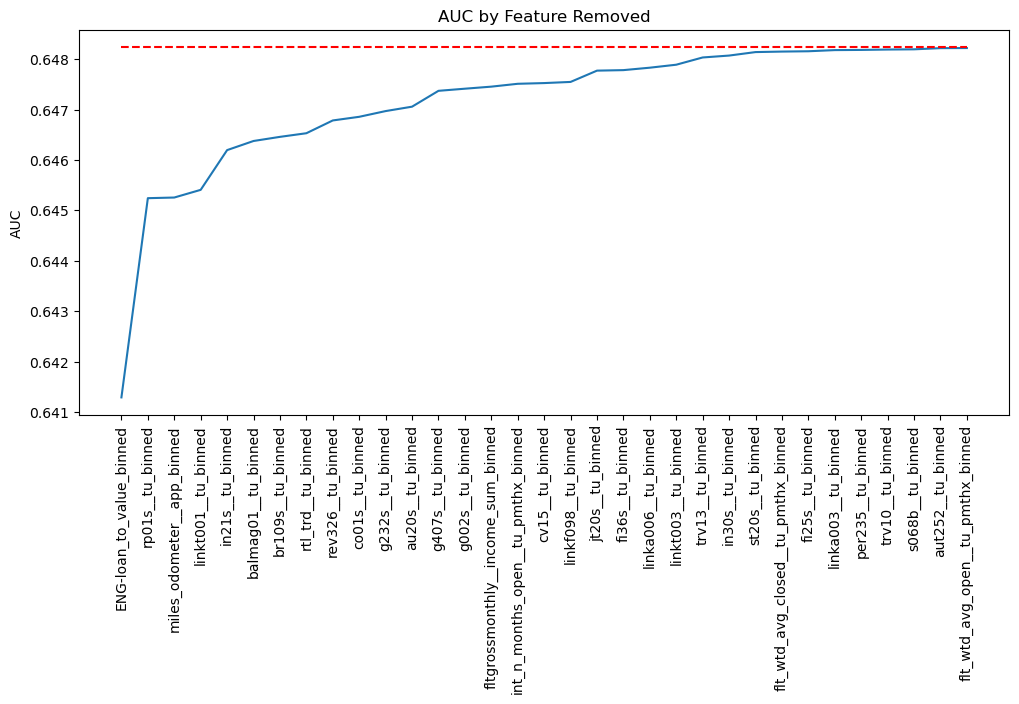

In [42]:
# plot
x = df_sensitivity['feature']
y = df_sensitivity['score']
z = df_sensitivity['target']
fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.plot(x, z, linestyle='--', color='red')
ax.set_xticklabels(x, rotation=90)
plt.show()

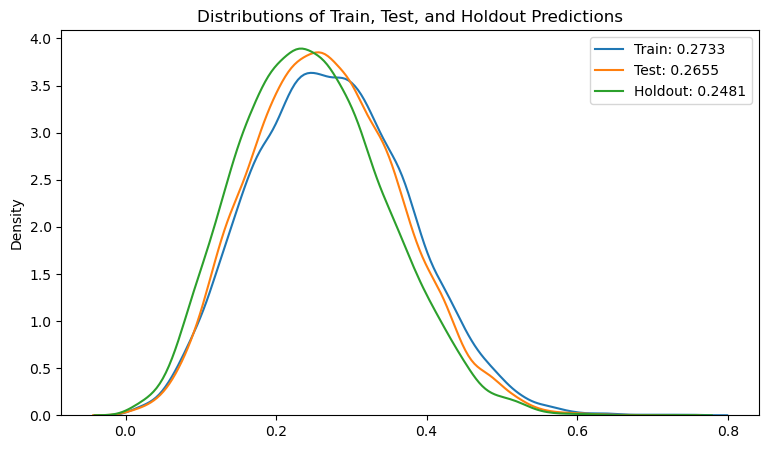

In [43]:
# rm
# list_cols_rm = list(df_tmp['feature'])
# list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_cols_rm]

# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
#     penalty='l1',
#     solver='liblinear',
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# save
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# upload to s3
str_bucket_key = f'{str_task}/{str_subtask}/{str_filename}'
upload_to_s3(
    str_local_path=str_local_path,
    str_bucket_key=str_bucket_key,
    str_bucket_name=str_project,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

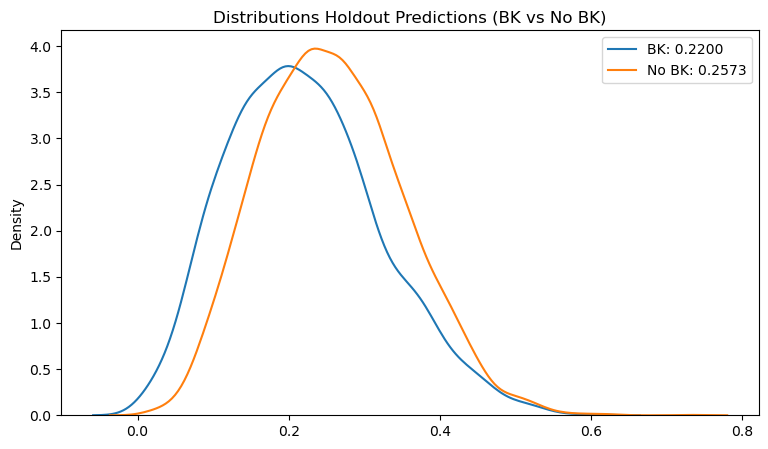

In [44]:
# holdout by bk non bk
df_tmp_bk = X_holdout.copy()
df_tmp_bk['yhat'] = list_predictions_holdout
list_predictions_bk = list(df_tmp_bk[df_tmp_bk['ENG-bk'] == 1]['yhat'])
list_predictions_nobk = list(df_tmp_bk[df_tmp_bk['ENG-bk'] == 0]['yhat'])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions Holdout Predictions (BK vs No BK)')
sns.kdeplot(list_predictions_bk, label=f'BK: {np.mean(list_predictions_bk):0.4f}')
sns.kdeplot(list_predictions_nobk, label=f'No BK: {np.mean(list_predictions_nobk):0.4f}')
# legend
ax.legend()

# save
str_filename = 'plt_distributions_bk.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

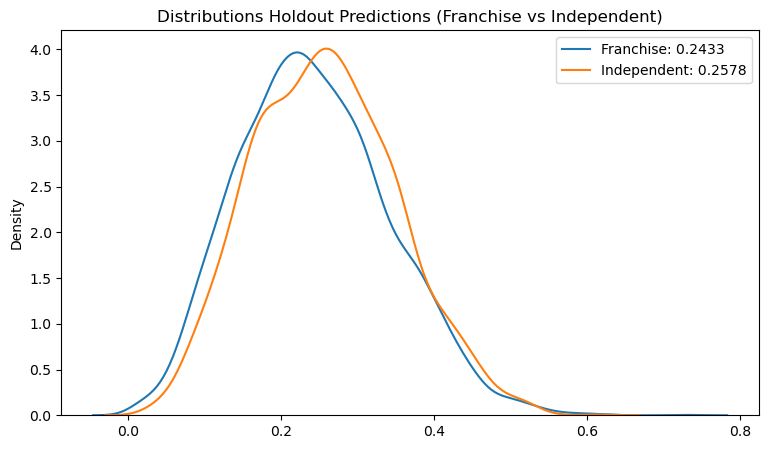

In [45]:
# holdout by franchise/ind
df_tmp_bk = X_holdout.copy()
df_tmp_bk['yhat'] = list_predictions_holdout
list_predictions_franchise = list(df_tmp_bk[df_tmp_bk['ENG-franchise'] == 1]['yhat'])
list_predictions_independent = list(df_tmp_bk[df_tmp_bk['ENG-franchise'] == 0]['yhat'])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions Holdout Predictions (Franchise vs Independent)')
sns.kdeplot(list_predictions_franchise, label=f'Franchise: {np.mean(list_predictions_franchise):0.4f}')
sns.kdeplot(list_predictions_independent, label=f'Independent: {np.mean(list_predictions_independent):0.4f}')
# legend
ax.legend()

# save
str_filename = 'plt_distributions_dealer.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

In [46]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6482
AUC Test: 0.6504
AUC Holdout: 0.6329

Logloss Train: 0.5587
Logloss Test: 0.5613
Logloss Holdout: 0.5269

KS Train: 0.2164
KS Test: 0.2219
KS Holdout: 0.2002


#### Get intercept

In [47]:
# get intercept
flt_intercept = cls_model_inference.intercept_[0]
print(f'Intercept: {flt_intercept}')

Intercept: -0.9790851578377979


In [48]:
# get feature importance
dict_map_descriptions_bin = {f'{key}_binned': val for key, val in dict_map_descriptions.items()}
df_tmp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
    list_cols_model=list_cols_scorecard,
    df=X_test,
)
# map desceription
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_feat_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,importance_abs,description
2,linkt001__tu_binned,-0.018050,0.018050,Number of non-military addresses in last 7 years
1,au20s__tu_binned,-0.016539,0.016539,Months since oldest auto trade opened
8,rtl_trd__tu_binned,-0.012721,0.012721,Number of retail trades
0,rev326__tu_binned,-0.012705,0.012705,Average Total Open-to-Buy for Revolving accoun...
6,br109s__tu_binned,-0.011817,0.011817,Number of bank revolving trades with past due ...
3,miles_odometer__app_binned,0.011778,0.011778,NaN
5,fltgrossmonthly__income_sum_binned,-0.010692,0.010692,NaN
4,balmag01__tu_binned,-0.009710,0.009710,Non-mortgage balance magnitude algorithm over ...
9,ENG-loan_to_value_binned,0.007732,0.007732,NaN
7,int_n_months_open__tu_pmthx_binned,-0.006530,0.006530,NaN


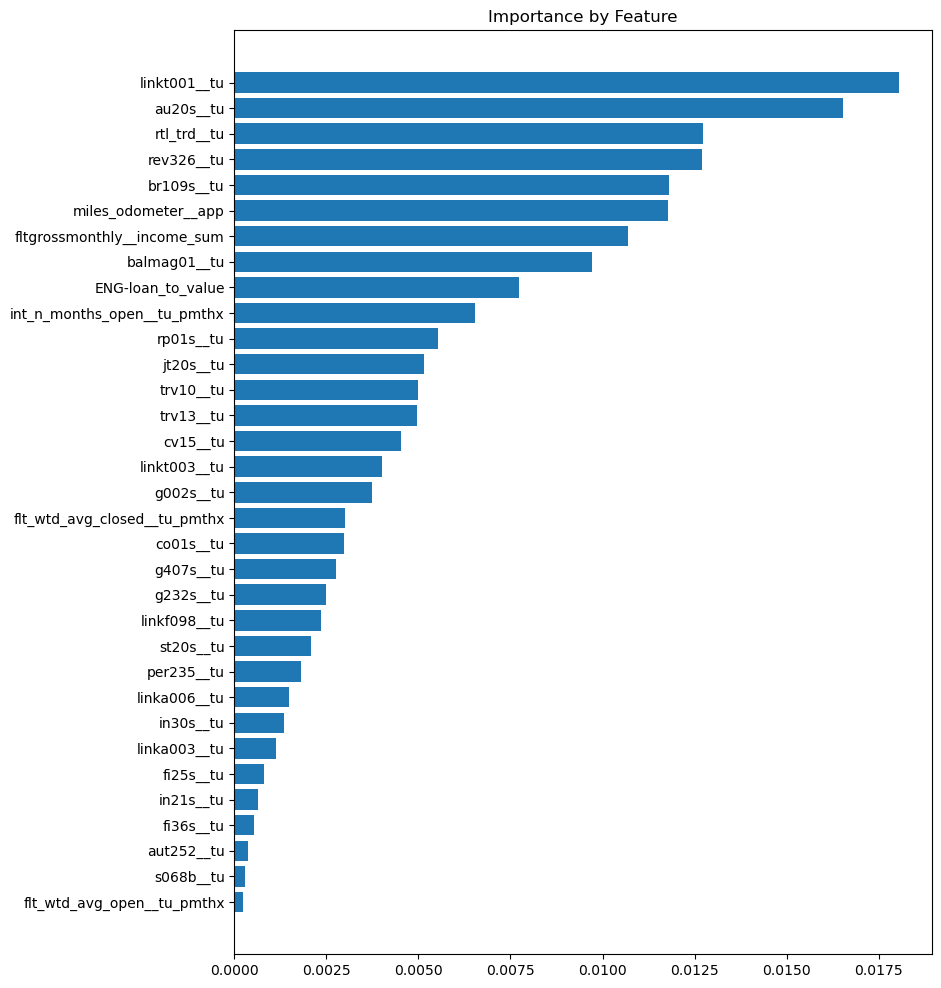

In [49]:
# plot
df_tmp.sort_values(by='importance_abs', ascending=True, inplace=True)
df_tmp['feature_tmp'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
x = df_tmp['feature_tmp']
y = df_tmp['importance_abs']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Importance by Feature')
ax.barh(x, y)

# save
str_filename = 'feat_importance.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

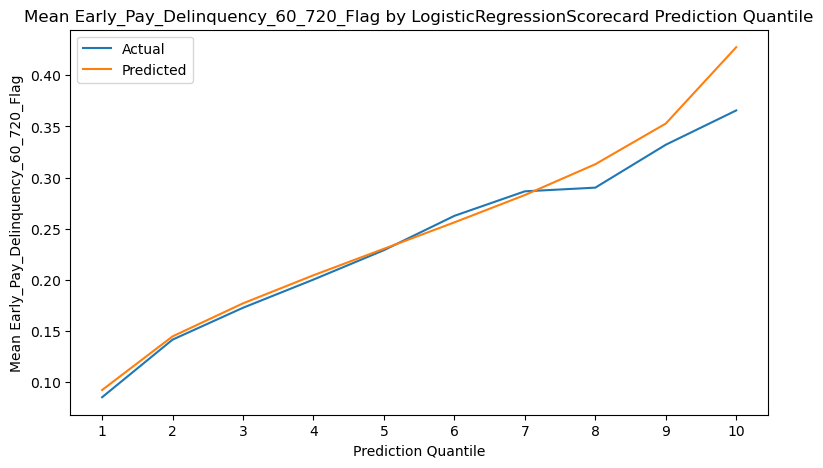

In [50]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

In [51]:
# # directions of predictions
# int_n_quantiles = 10
# get_directions_of_predictions_for_scorecard(
#     X=X_holdout.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_scorecard,
#     df_bins=df_bins,
# )

#### Show scorecard

In [52]:
# copy df_bins
df_identity = df_bins[df_bins['feature'].isin(list_cols_scorecard)].copy()

df_coef = pd.DataFrame({
    'feature': cls_model_inference.feature_names_in_,
    'coef': cls_model_inference.coef_[0],
})
# create dictionary
dict_map_coef = dict(zip(df_coef['feature'], df_coef['coef']))

# map to df_identity
df_identity['coef'] = df_identity['feature'].map(dict_map_coef)

# multiply by bin value
df_identity['contribution'] = df_identity['bin'] * df_identity['coef']

# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,True], inplace=True)

# get description
df_identity['description'] = df_identity['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_scorecard.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity.to_csv(str_local_path, index=False)

# show
df_identity

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
58,ENG-loan_to_value_binned,2.147141,0.185462,0.775976,95,0.003797,0.042105,1,-0.910839,-1.955699,NaN
59,ENG-loan_to_value_binned,1.034299,0.776875,0.894086,178,0.007115,0.117978,2,-0.910839,-0.942079,NaN
60,ENG-loan_to_value_binned,0.624390,0.894686,1.012695,942,0.037653,0.167728,3,-0.910839,-0.568718,NaN
61,ENG-loan_to_value_binned,0.215360,1.012821,1.130922,3089,0.123471,0.232761,4,-0.910839,-0.196158,NaN
62,ENG-loan_to_value_binned,0.041781,1.130961,1.249133,6422,0.256695,0.265182,5,-0.910839,-0.038056,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2100,trv10__tu_binned,-0.008654,6.000000,9.000000,4776,0.190903,0.275126,2,-0.181721,0.001573,Number of months non-mortgage balance decrease...
2099,trv10__tu_binned,-0.114784,0.000000,5.000000,13481,0.538852,0.296788,1,-0.181721,0.020859,Number of months non-mortgage balance decrease...
2109,trv13__tu_binned,0.194061,2.000000,14.000000,1957,0.078224,0.236587,3,-0.371094,-0.072015,Number of revolving high credit increases YOY
2108,trv13__tu_binned,0.095893,1.000000,1.000000,2881,0.115157,0.254773,2,-0.371094,-0.035585,Number of revolving high credit increases YOY


#### Graph it

100%|██████████| 33/33 [00:01<00:00, 21.53it/s]


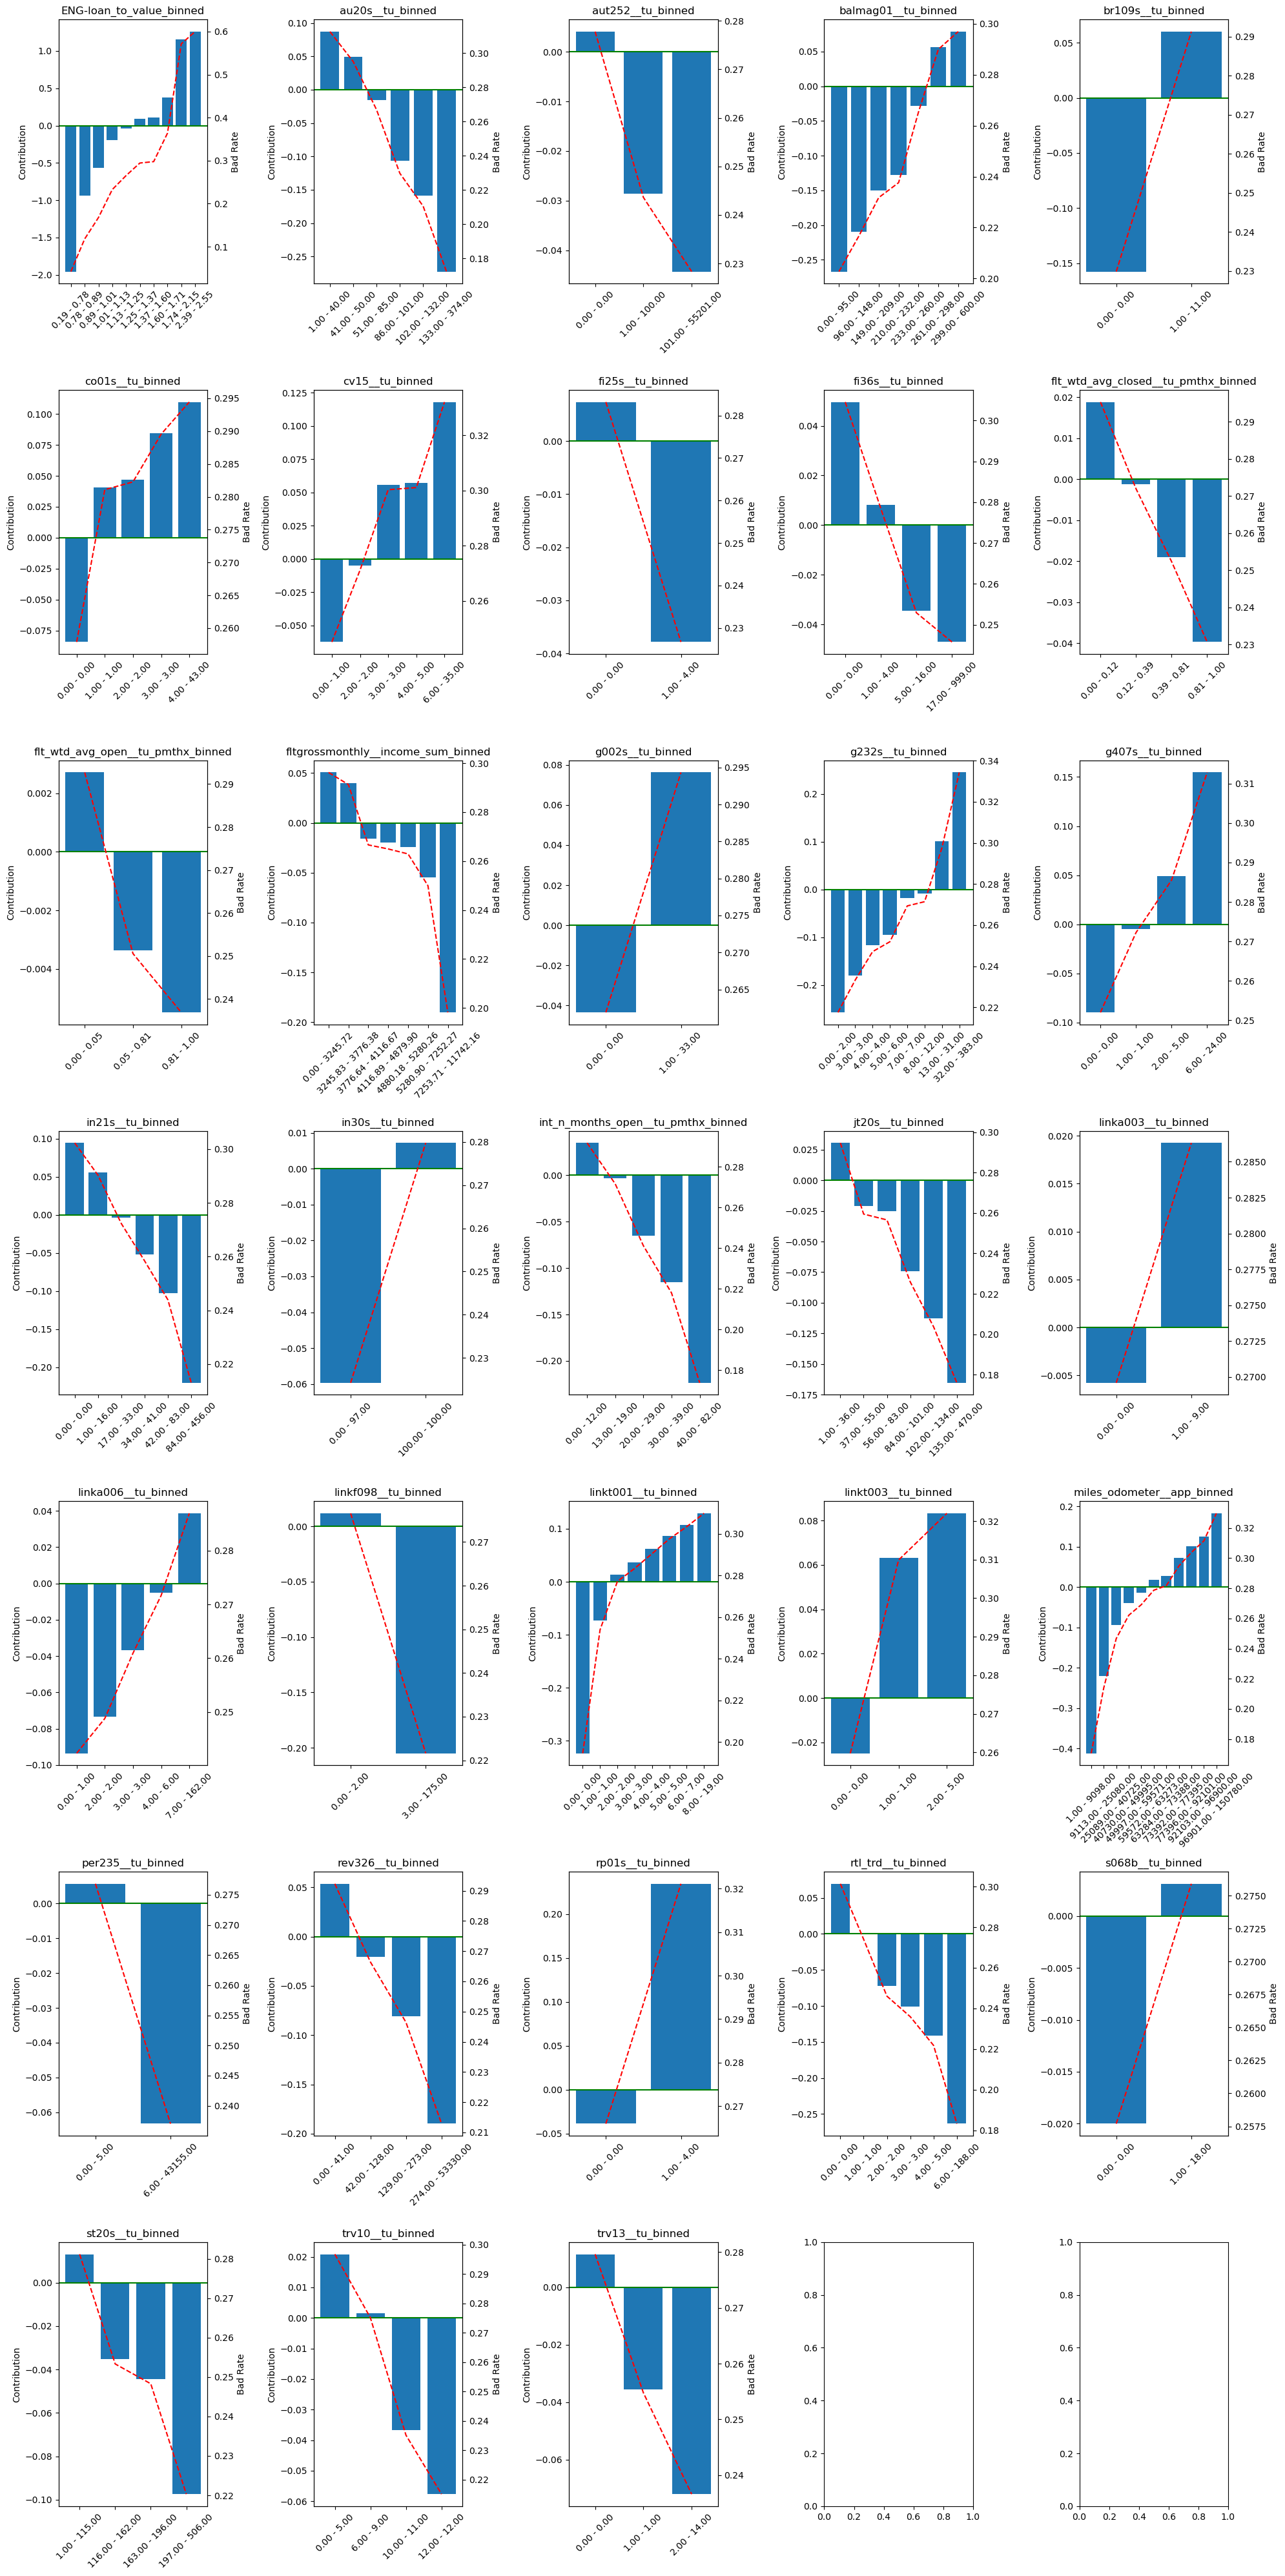

In [53]:
# get the unique values
list_feats_unique = list(df_identity['feature'].unique())

# plot
fig, ax = plt.subplots(nrows=int_nrows, ncols=int_ncols, figsize=(20, 40))

# iterate through features
counter = 0
int_row_start = 0
int_col_start = 0
for str_feat in tqdm(list_feats_unique):
    # logic for row, col
    if (int_col_start % int_ncols == 0) and (counter != 0):
        # add 1 to row
        int_row_start += 1
        # reset int_col_start
        int_col_start = 0
    else:
        pass
    
    # get row
    int_idx_row = int_row_start
    # get col
    int_idx_col = int_col_start
    # subset
    df_tmp = df_identity[df_identity['feature'] == str_feat].copy()
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create label
    df_tmp['label'] = df_tmp.apply(
        lambda x: f'{x["min"]:0.2f} - {x["max"]:0.2f}',
        axis=1,
    )
    # x and y
    x = df_tmp['label']
    y = df_tmp['contribution']
    z = df_tmp['target']
    # plot
    ax[int_idx_row, int_idx_col].set_title(str_feat)
    ax[int_idx_row, int_idx_col].set_ylabel('Contribution')
    ax[int_idx_row, int_idx_col].bar(x, y)
    ax[int_idx_row, int_idx_col].set_xticklabels(x, rotation=45)
    # horizontal line at 0
    ax[int_idx_row, int_idx_col].axhline(0, color='green')
    # second y
    ax2 = ax[int_idx_row, int_idx_col].twinx()
    ax2.set_ylabel('Bad Rate')
    ax2.plot(x, z, color='red', linestyle='--')
    # add
    counter += 1
    int_col_start += 1

# fix overlap
plt.tight_layout()

# save
str_filename = 'plt_scorecard.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Programmatically find the flipped features

In [54]:
list_str_col = list(df_identity['feature'].unique())
list_cols_flip = []
for str_col in tqdm(list_str_col):
    # subset
    df_tmp = df_identity[df_identity['feature'] == str_col].copy()
    # sort by contribution lowest to highest
    df_tmp.sort_values(by='contribution', ascending=True, inplace=True)
    # get the first bad rate
    flt_bad_rate_first = df_tmp['target'].iloc[0]
    # get the last bad rate
    flt_bad_rate_last = df_tmp['target'].iloc[-1]
    # make sure the last bad rate is larger than the first
    flt_diff = flt_bad_rate_last - flt_bad_rate_first
    # if the difference is negative
    if flt_diff < 0:
        # the feature flipped
        list_cols_flip.append(str_col)
    else:
        pass

# print message
int_ncols = len(list_cols_flip)
print(f'There are {int_ncols} features that flipped, please manually review and remove:')
for col in list_cols_flip:
    col = col.split('_binned')[0]
    print(f"'{col}',")

100%|██████████| 33/33 [00:00<00:00, 350.79it/s]

There are 0 features that flipped, please manually review and remove:


#### Show identity

In [55]:
df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
58,ENG-loan_to_value_binned,2.147141,0.185462,0.775976,95,0.003797,0.042105,1,-0.910839,-1.955699,NaN
7,miles_odometer__app_binned,0.603982,1.000000,9098.000000,1442,0.057639,0.170596,1,-0.682630,-0.412296,NaN
74,linkt001__tu_binned,0.442737,0.000000,0.000000,2461,0.098369,0.194636,1,-0.730494,-0.323416,Number of non-military addresses in last 7 years
238,au20s__tu_binned,0.592250,133.000000,374.000000,1370,0.054761,0.172263,6,-0.460362,-0.272650,Months since oldest auto trade opened
2119,balmag01__tu_binned,0.392063,0.000000,95.000000,1258,0.050284,0.202703,1,-0.680860,-0.266940,Non-mortgage balance magnitude algorithm over ...
2036,rtl_trd__tu_binned,0.516963,6.000000,188.000000,1446,0.057798,0.183264,6,-0.509780,-0.263537,Number of retail trades
760,g232s__tu_binned,0.302648,0.000000,2.000000,1779,0.071109,0.217538,1,-0.849004,-0.256949,Number of inquiries (includes duplicates)
2404,int_n_months_open__tu_pmthx_binned,0.581781,40.000000,82.000000,1997,0.079823,0.173761,5,-0.384280,-0.223567,NaN
902,in21s__tu_binned,0.329352,84.000000,456.000000,1305,0.052162,0.213027,6,-0.669729,-0.220576,Months since most recent installment trade opened
2234,linkf098__tu_binned,0.278904,3.000000,175.000000,1444,0.057718,0.221607,2,-0.734907,-0.204968,Number of satisfactory trades


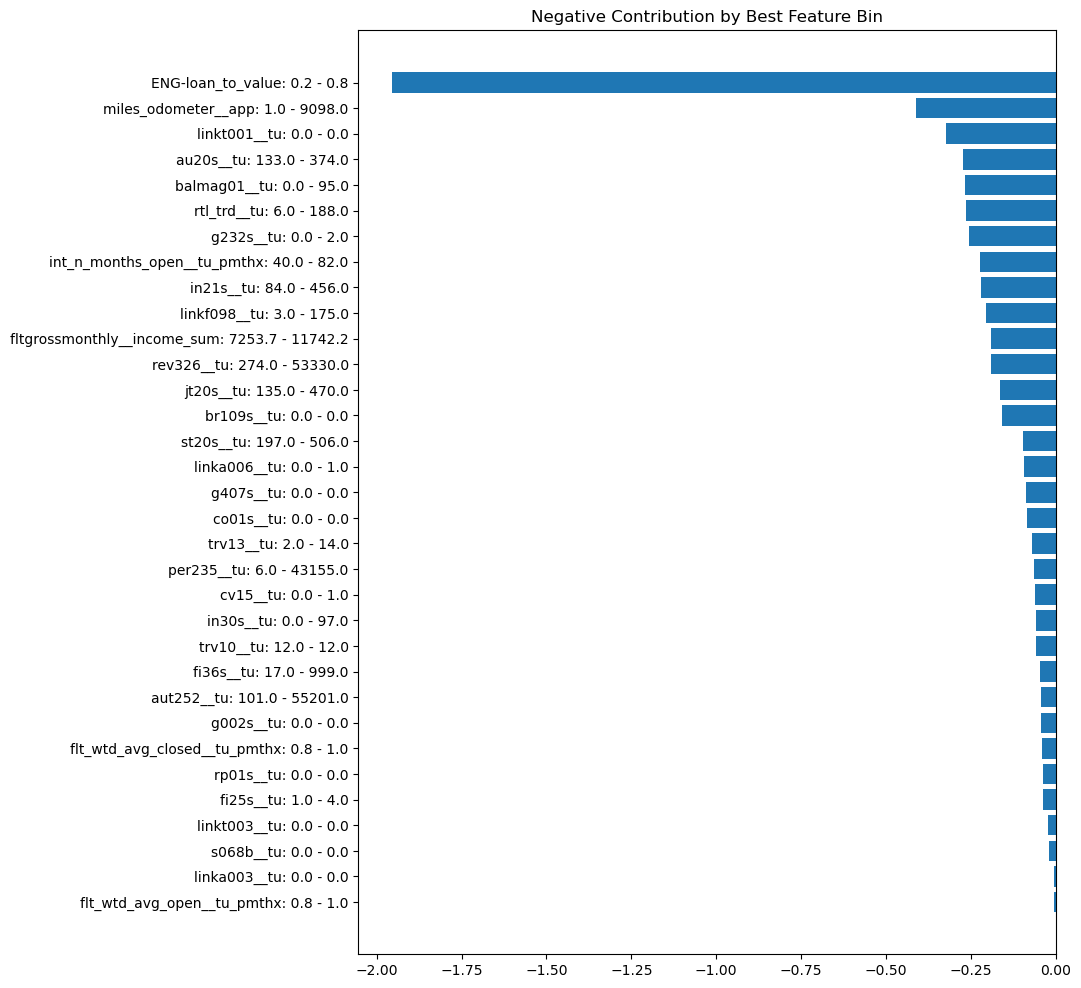

In [56]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=False, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Negative Contribution by Best Feature Bin')
ax.barh(x, y)

# save
str_filename = 'best_bin.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Show what is not our identity

In [57]:
# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,False], inplace=True)

df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub_anti.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
2405,flt_wtd_avg_open__tu_pmthx_binned,-0.095171,0.000000,0.047619,15599,0.623511,0.292711,1,-0.028512,0.002714,NaN
1109,s068b__tu_binned,-0.012575,1.000000,18.000000,21576,0.862419,0.275908,2,-0.248511,0.003125,Number of non-medical third party collections
1774,aut252__tu_binned,-0.021987,0.000000,0.000000,22398,0.895275,0.277793,1,-0.184156,0.004049,Average Aggregate Excess Payment for Auto acco...
1785,per235__tu_binned,-0.017208,0.000000,5.000000,22862,0.913822,0.276835,1,-0.330154,0.005681,Aggregate Excess Payment for Personal Loan acc...
917,in30s__tu_binned,-0.031869,100.000000,100.000000,22146,0.885203,0.279780,2,-0.226322,0.007213,Percentage of open installment trades > 50% of...
523,fi25s__tu_binned,-0.048616,0.000000,0.000000,20691,0.827045,0.283167,1,-0.151660,0.007373,Number of currently open and satisfactory fina...
2107,trv13__tu_binned,-0.031143,0.000000,0.000000,20180,0.806619,0.279633,1,-0.371094,0.011557,Number of revolving high credit increases YOY
2233,linkf098__tu_binned,-0.015914,0.000000,2.000000,23574,0.942282,0.276576,1,-0.734907,0.011695,Number of satisfactory trades
1124,st20s__tu_binned,-0.038709,1.000000,115.000000,19793,0.791150,0.281160,1,-0.340024,0.013162,Months since oldest student loan trade opened
2430,flt_wtd_avg_closed__tu_pmthx_binned,-0.107723,0.000000,0.124183,14327,0.572668,0.295317,1,-0.174973,0.018849,NaN


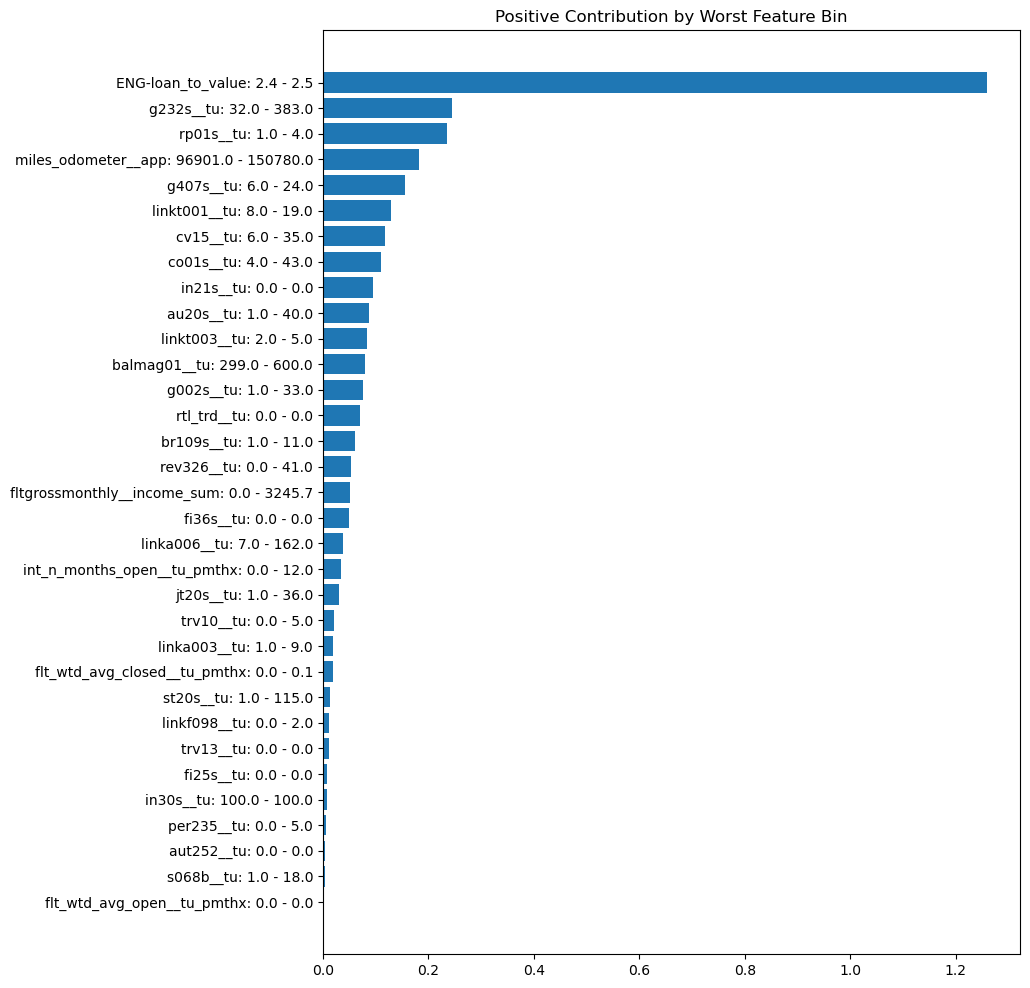

In [58]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Positive Contribution by Worst Feature Bin')
ax.barh(x, y)

# save
str_filename = 'worst_bin.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()